# Rank-Response Analysis Tutorial

This tutorial demonstrates how to conduct comprehensive rank-response analysis using tfbpapi to compare binding data with perturbation responses across multiple datasets.

## Overview

Rank-response analysis evaluates whether targets with stronger binding evidence are more likely to show transcriptional responses upon regulator perturbation. This approach helps validate functional relevance of binding data.

### Datasets Used
- **Binding data**: Calling Cards, ChEC-seq, ChIP-chip
- **Perturbation data**: McIsaac (ZEV system), Kemmeren (overexpression), Mahendrawada (RNA-seq)

### Analysis Strategy
1. Load and filter datasets to common regulators/targets
2. Rank targets by binding strength for each regulator
3. Label targets as responsive/non-responsive based on perturbation data
4. Perform binned analysis to assess rank-response relationship
5. Compare results across different data combinations

In [61]:
import pandas as pd
from tfbpapi.HfQueryAPI import HfQueryAPI
from tfbpapi.RankResponseAnalysis import RankResponseAnalyzer
from tfbpapi.datainfo.datacard import DataCard
from tfbpapi.errors import DataCardError, HfDataFetchError
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plotting
plt.style.use('default')
sns.set_palette("husl")

## Dataset Exploration with DataCard

Before loading data, let's explore dataset structure and metadata using the DataCard interface.

In [62]:
# Explore dataset structure using DataCard
print("Exploring dataset structures...")

datasets_to_explore = [
    "BrentLab/callingcards",
    "BrentLab/mahendrawada_2025", 
    "BrentLab/harbison_2004",
    "BrentLab/hackett_2020",
    "BrentLab/kemmeren_2014"
]

dataset_info = {}

for repo_id in datasets_to_explore:
    try:
        print(f"\n{'='*50}")
        print(f"Exploring {repo_id}")

        # Create DataCard instance
        datacard = DataCard(repo_id)
        card = datacard.dataset_card

        # DatasetCard doesn't have dataset_type directly - it's on individual configs
        dataset_types = [config.dataset_type.value for config in card.configs]
        print(f"Dataset types in configs: {set(dataset_types)}")
        print(f"Configurations: {len(card.configs)}")

        # Store dataset info for later use
        dataset_info[repo_id] = {
            'datacard': datacard,
            'card': card,
            'configs': {config.config_name: config for config in card.configs}
        }

        # Display configuration details
        for config in card.configs:
            print(f"\nConfig: {config.config_name}")
            print(f"  Type: {config.dataset_type.value}")
            print(f"  Features: {len(config.dataset_info.features) if config.dataset_info.features else 0}")

            if config.dataset_info.features:
                # Show regulator and target fields if available
                feature_names = [f.name for f in config.dataset_info.features]
                regulator_fields = [f for f in feature_names if 'regulator' in f.lower()]
                target_fields = [f for f in feature_names if 'target' in f.lower()]

                if regulator_fields:
                    print(f"  Regulator fields: {regulator_fields}")
                if target_fields:
                    print(f"  Target fields: {target_fields}")

            if config.metadata_fields:
                print(f"  Metadata fields: {config.metadata_fields}")

    except (DataCardError, HfDataFetchError) as e:
        print(f"Error exploring {repo_id}: {e}")
        continue
    except Exception as e:
        print(f"Unexpected error exploring {repo_id}: {e}")
        continue

print(f"\n{'='*50}")
print(f"Successfully explored {len(dataset_info)} datasets")

Exploring dataset structures...

Exploring BrentLab/callingcards
Dataset types in configs: {'genome_map', 'annotated_features', 'metadata'}
Configurations: 4

Config: annotated_features
  Type: annotated_features
  Features: 13
  Regulator fields: ['regulator_locus_tag', 'regulator_symbol']
  Target fields: ['target_locus_tag', 'target_symbol']

Config: genome_map
  Type: genome_map
  Features: 7

Config: annotated_features_meta
  Type: metadata
  Features: 9
  Regulator fields: ['regulator_locus_tag', 'regulator_symbol']

Config: genome_map_meta
  Type: metadata
  Features: 7
  Regulator fields: ['regulator_locus_tag', 'regulator_symbol']

Exploring BrentLab/mahendrawada_2025
Dataset types in configs: {'genome_map', 'annotated_features', 'metadata', 'genomic_features'}
Configurations: 6

Config: genomic_features
  Type: genomic_features
  Features: 24

Config: mahendrawada_2025_metadata
  Type: metadata
  Features: 7
  Regulator fields: ['regulator_locus_tag', 'regulator_symbol']

Con

In [63]:
## Initialize dataset connections and load data


In [64]:

print("Initializing HfQueryAPI connections...")

mahendrawada_2025 = HfQueryAPI(repo_id="BrentLab/mahendrawada_2025")
hackett_2020 = HfQueryAPI(repo_id="BrentLab/hackett_2020")
callingcards = HfQueryAPI(repo_id="BrentLab/callingcards")
harbison_2004 = HfQueryAPI(repo_id="BrentLab/harbison_2004") 
kemmeren_2014 = HfQueryAPI(repo_id="BrentLab/kemmeren_2014")

print("All API connections initialized")

Initializing HfQueryAPI connections...
All API connections initialized


In [65]:
# Get metadata from each dataset to find common regulators
print("Getting metadata from datasets...")

harbison_meta = harbison_2004.get_metadata("harbison_2004")
kemmeren_meta = kemmeren_2014.get_metadata("kemmeren_2014") 
callingcards_meta = callingcards.get_metadata("annotated_features")
mahendrawada_checseq_meta = mahendrawada_2025.get_metadata("mahendrawada_chec_seq")
mahendrawada_rnaseq_meta = mahendrawada_2025.get_metadata("rna_seq")
hackett_2020_meta = hackett_2020.get_metadata("hackett_2020")

print("All metadata loaded")

# Get the intersection of common regulators
common_regulators = (set(mahendrawada_rnaseq_meta.regulator_locus_tag.unique())
                    & set(mahendrawada_checseq_meta.regulator_locus_tag.unique())
                    & set(hackett_2020_meta.regulator_locus_tag.unique())
                    & set(callingcards_meta.regulator_locus_tag.unique())
                    & set(harbison_meta.regulator_locus_tag.unique())
                    & set(kemmeren_meta.regulator_locus_tag.unique()))

print(f"Found {len(common_regulators)} common regulators across all datasets")

# Create proper SQL IN clause
if common_regulators:
    regulator_clause = "(" + ", ".join(f"'{reg}'" for reg in common_regulators) + ")"

Getting metadata from datasets...
All metadata loaded
Found 81 common regulators across all datasets


## Filter the data

In [66]:
# Load and filter calling cards data with passing experiments
print("Loading calling cards quality filter...")

passing_cc = pd.read_csv("./passing_callingcards.csv")
db_ids_as_str = [str(id) for id in passing_cc.id.unique()]

# filter the callingcards_data on the db_id column using passing_cc.id
db_ids = callingcards_meta[callingcards_meta.db_id.isin(db_ids_as_str)].id
cc_ids_clause = "(" + ", ".join(f"'{db_id}'" for db_id in db_ids) + ")"

print(f"Found {len(db_ids)} passing calling cards experiments")

# Apply dataset-specific filters
print("Applying dataset-specific filters...")

hackett_2020.set_sql_filter(
    "hackett_2020",
    f"""
        time = 15 
        AND mechanism = 'ZEV' 
        AND restriction = 'P' 
        AND regulator_locus_tag IN {regulator_clause}
    """)

mahendrawada_2025.set_sql_filter(
    "mahendrawada_chec_seq",
    f"""
    regulator_locus_tag IN {regulator_clause}
    """)

mahendrawada_2025.set_sql_filter(
    "rna_seq",
    f"""
    regulator_locus_tag IN {regulator_clause}
    """)

callingcards.set_sql_filter(
    "annotated_features",
    f"""
    regulator_locus_tag IN {regulator_clause} 
    AND id IN {cc_ids_clause}
    """)

harbison_2004.set_sql_filter(
      "harbison_2004",
      f"""
      regulator_locus_tag IN {regulator_clause} 
      AND condition = 'YPD'
      """)

print("All filters applied")

Loading calling cards quality filter...
Found 81 passing calling cards experiments
Applying dataset-specific filters...
All filters applied


In [67]:
# Load initial datasets to determine final common regulators and targets
print("Loading initial datasets...")

mcisaac = hackett_2020.query("SELECT * FROM hackett_2020", "hackett_2020")
mahendrawada_chec = mahendrawada_2025.query("SELECT * FROM mahendrawada_chec_seq", "mahendrawada_chec_seq") 
mahendrawada_perturb = mahendrawada_2025.query("SELECT * FROM rna_seq", "rna_seq")
callingcards_data = callingcards.query("SELECT * FROM annotated_features", "annotated_features")
harbison_data = harbison_2004.query("SELECT * FROM harbison_2004", "harbison_2004")
mahendrawada_features = mahendrawada_2025.query("SELECT * FROM genomic_features", "genomic_features")

print("Initial datasets loaded")

# After running your current queries, check what you actually got
actual_regulators = {
    'mcisaac': set(mcisaac.regulator_locus_tag.unique()),
    'mahendrawada_chec': set(mahendrawada_chec.regulator_locus_tag.unique()),
    'callingcards': set(callingcards_data.regulator_locus_tag.unique()),
    'harbison': set(harbison_data.regulator_locus_tag.unique())
}

for name, regulators in actual_regulators.items():
    print(f"{name}: {len(regulators)} regulators")

final_common = set.intersection(*actual_regulators.values())
print(f"Final intersection: {len(final_common)} regulators")

final_common_clause = "(" + ", ".join(f"'{reg}'" for reg in final_common) + ")"

Loading initial datasets...
Initial datasets loaded
mcisaac: 61 regulators
mahendrawada_chec: 81 regulators
callingcards: 46 regulators
harbison: 81 regulators
Final intersection: 33 regulators


In [68]:
# Find common targets across all datasets
print("Finding common targets...")

common_targets = (set(mcisaac.target_locus_tag.unique())
                    & set(mahendrawada_features.locus_tag.unique())
                    & set(callingcards_data.target_locus_tag.unique())
                    & set(harbison_data.target_locus_tag.unique()))

print(f"Found {len(common_targets)} common targets")

if common_targets:
    target_clause = "(" + ", ".join(f"'{tgt}'" for tgt in common_targets) + ")"

# Load final datasets with both regulator and target filtering  
print("Loading final datasets with complete filtering...")

mcisaac = hackett_2020.query(f"""
                             SELECT *
                             FROM hackett_2020
                             WHERE regulator_locus_tag in {final_common_clause} 
                             AND target_locus_tag IN {target_clause}
                             """, "hackett_2020")

mahendrawada_perturb = mahendrawada_2025.query(f"""
                                               SELECT *
                                               FROM rna_seq
                                               WHERE regulator_locus_tag IN {final_common_clause} 
                                               AND target_locus_tag IN {target_clause}
                                               """, "rna_seq")

kemmeren = kemmeren_2014.query(f"""
                               SELECT * FROM kemmeren_2014 WHERE regulator_locus_tag IN {final_common_clause} 
                               AND target_locus_tag IN {target_clause} 
                               AND variable_in_wt = 0
                               """,
                                 "kemmeren_2014")

mahendrawada_chec = mahendrawada_2025.query(f"SELECT * FROM mahendrawada_chec_seq WHERE regulator_locus_tag IN {final_common_clause} AND target_locus_tag IN {target_clause}", "mahendrawada_chec_seq")

callingcards_data = callingcards.query(f"SELECT * FROM annotated_features WHERE regulator_locus_tag IN {final_common_clause} AND target_locus_tag IN {target_clause}",
                                 "annotated_features")

harbison = harbison_2004.query(f"SELECT * FROM harbison_2004 WHERE regulator_locus_tag IN {final_common_clause} AND target_locus_tag IN {target_clause}",
                               "harbison_2004")

print("Final datasets loaded with complete filtering")

# Print final dataset sizes
datasets_info = [
    ('McIsaac', mcisaac), ('Kemmeren', kemmeren), ('Mahendrawada RNA-seq', mahendrawada_perturb),
    ('Calling Cards', callingcards_data), ('Mahendrawada ChEC', mahendrawada_chec), ('Harbison', harbison)
]

for name, data in datasets_info:
    if len(data) > 0:
        regulators = data['regulator_locus_tag'].nunique() if 'regulator_locus_tag' in data.columns else 0
        print(f"{name}: {len(data):,} rows, {regulators} regulators")
    else:
        print(f"{name}: No data loaded")

Finding common targets...
Found 5525 common targets
Loading final datasets with complete filtering...
Final datasets loaded with complete filtering
McIsaac: 187,884 rows, 33 regulators
Kemmeren: 178,332 rows, 33 regulators
Mahendrawada RNA-seq: 4,411 rows, 33 regulators
Calling Cards: 182,325 rows, 33 regulators
Mahendrawada ChEC: 22,478 rows, 33 regulators
Harbison: 182,952 rows, 33 regulators


In [69]:
## 2. Rank Binding Data by Strength

In [70]:

# Rank binding datasets by strength (stronger binding = lower rank)
callingcards_ranked = (callingcards_data
      .sort_values(['regulator_locus_tag', 'poisson_pval', 'callingcards_enrichment'],
                   ascending=[True, True, False],  # Lower p-value, higher enrichment = stronger
                   kind='stable')
      .reset_index(drop=True)
  )

mahendrawada_chec_ranked = (mahendrawada_chec
      .sort_values(['regulator_locus_tag', 'peak_score'],
                   ascending=[True, False],  # Higher peak score = stronger
                   kind='stable')
      .reset_index(drop=True)
  )

harbison_ranked = (harbison
      .sort_values(['regulator_locus_tag', 'pvalue', 'effect'],
                   ascending=[True, True, False],  # Lower p-value, higher effect = stronger
                   kind='stable')
      .reset_index(drop=True)
  )

print("Binding datasets ranked by strength")

Binding datasets ranked by strength


In [71]:

def label_by_mcisaac(df):
    """Label targets as responsive based on McIsaac perturbation data."""
    out = df.merge(
        mcisaac[['regulator_locus_tag', 'target_locus_tag', 'log2_shrunken_timecourses']],
        on=['regulator_locus_tag', 'target_locus_tag'],
        how='left',
    )

    out['is_responsive'] = (
        out.get('log2_shrunken_timecourses', pd.Series(0)).fillna(0).abs() > 0)

    return out

def label_by_kemmeren(df):
    """Label targets as responsive based on Kemmeren perturbation data."""  
    out = df.merge(
        kemmeren[['regulator_locus_tag', 'target_locus_tag', 'Madj', 'pval']],
        on=['regulator_locus_tag', 'target_locus_tag'],
        how='left',
    )

    out['is_responsive'] = (
        out.get('pval', pd.Series(1)).fillna(1) <= 0.05)

    return out

def label_by_mahendrawada_rnaseq(df):
    """Label targets as responsive based on Mahendrawada RNA-seq data."""
    out = df.merge(
        mahendrawada_perturb[['regulator_locus_tag', 'target_locus_tag', 'log2fc']],
        on=['regulator_locus_tag', 'target_locus_tag'],
        how='left',
    )

    out['is_responsive'] = ~out.log2fc.isna()

    return out

print("Labeling functions defined")

Labeling functions defined


In [72]:

def get_rr_results(df):
    """
    Perform rank-response analysis for each regulator in the dataset.

    :param df: DataFrame with ranked binding data and responsive labels

    :returns:    DataFrame with bin-level results for all regulators
    """
    res_dict = {}

    # For each regulator separately
    for regulator in df['regulator_locus_tag'].unique():
        regulator_data = df[
            df['regulator_locus_tag'] == regulator
        ]

        try:
            analyzer = RankResponseAnalyzer(
                data=regulator_data[['target_locus_tag', 'is_responsive']],
                target_col='target_locus_tag',
                responsive_col='is_responsive',
                bin_size=5  # Small bin size for detailed analysis
            )

            results = analyzer.get_bin_summary()
            res_dict[regulator] = results

        except Exception as e:
            print(f"Warning: Failed to analyze {regulator}: {e}")
            continue

    if not res_dict:
        return pd.DataFrame()

    return (pd.concat(res_dict, names=['regulator_locus_tag', 'original_index'])
            .reset_index(level=0)
            .reset_index(drop=True))

def combine_rr_results(ranked_df, binding_source):
    """
    Generate rank-response results for all perturbation sources and combine filtered results.

    :param ranked_df: DataFrame with ranked binding data
    :param binding_source: String identifier for the binding data source

    :returns: Combined DataFrame with bin==5 results from all perturbation sources
    """
    print(f"Analyzing {binding_source} binding data...")

    # Generate results for each perturbation source
    cc_mcisaac_rr = get_rr_results(label_by_mcisaac(ranked_df))
    cc_kem_rr = get_rr_results(label_by_kemmeren(ranked_df))
    cc_mahendrawada_rr = get_rr_results(label_by_mahendrawada_rnaseq(ranked_df))

    # Add source columns to each result
    cc_mcisaac_rr['binding_source'] = binding_source
    cc_mcisaac_rr['perturbation_source'] = 'mcisaac'

    cc_kem_rr['binding_source'] = binding_source
    cc_kem_rr['perturbation_source'] = 'kemmeren'

    cc_mahendrawada_rr['binding_source'] = binding_source
    cc_mahendrawada_rr['perturbation_source'] = 'mahendrawada_rnaseq'

    # Filter to bin==5 (strongest binding bin) and combine
    bin5_results = [cc_mcisaac_rr[cc_mcisaac_rr.bin == 5],
                    cc_kem_rr[cc_kem_rr.bin == 5],
                    cc_mahendrawada_rr[cc_mahendrawada_rr.bin == 5]]

    combined = pd.concat(bin5_results, ignore_index=True)

    # Find regulators that have observations from all 3 perturbation sources
    regulator_counts = combined.groupby('regulator_locus_tag')['perturbation_source'].nunique()
    complete_regulators = regulator_counts[regulator_counts == 3].index

    # Filter to only keep rows for regulators with all 3 perturbation sources
    final_result = combined[combined.regulator_locus_tag.isin(complete_regulators)]

    print(f"Analysis complete: {len(complete_regulators)} regulators with complete data")

    return final_result

print("Analysis functions defined")

Analysis functions defined


In [73]:
def rank_by_binding_strength(df, binding_cols, ascending_order):
    """
    Rank targets by binding strength within each regulator group.

    :param df: DataFrame with binding data
    :param binding_cols: List of columns to sort by
    :param ascending_order: List of boolean values for sort order
    """
    return (df
            .sort_values(['regulator_locus_tag'] + binding_cols, 
                        ascending=[True] + ascending_order, 
                        kind='stable')
            .reset_index(drop=True))

# Rank binding datasets
callingcards_ranked = rank_by_binding_strength(
    callingcards_data,
    ['poisson_pval', 'callingcards_enrichment'],
    [True, False]  # Lower p-value and higher enrichment = stronger binding
)

mahendrawada_chec_ranked = rank_by_binding_strength(
    mahendrawada_chec,
    ['peak_score'],
    [False]  # Higher peak score = stronger binding
)

harbison_ranked = rank_by_binding_strength(
    harbison_data,
    ['pvalue', 'effect'],
    [True, False]  # Lower p-value and higher effect = stronger binding
)

print("Binding data ranked by strength")

Binding data ranked by strength


## Rank by binding and label each target as responsive or non-responsive

In [74]:
# Run analysis for all available binding datasets
print("Executing comprehensive rank-response analysis...")
print("This will analyze each binding dataset against all perturbation sources...")

# Execute analysis for each binding dataset
cc_rr_res = combine_rr_results(callingcards_ranked, "callingcards")
chec_rr_res = combine_rr_results(mahendrawada_chec_ranked, "mahendrawada_chec") 
harb_rr_res = combine_rr_results(harbison_ranked, "harbison")

print(f"\n{'='*50}")
print("Individual dataset results:")
print(f"Calling Cards: {len(cc_rr_res)} result rows")
print(f"ChEC-seq: {len(chec_rr_res)} result rows") 
print(f"Harbison: {len(harb_rr_res)} result rows")

Executing comprehensive rank-response analysis...
This will analyze each binding dataset against all perturbation sources...
Analyzing callingcards binding data...
Analysis complete: 33 regulators with complete data
Analyzing mahendrawada_chec binding data...
Analysis complete: 33 regulators with complete data
Analyzing harbison binding data...
Analysis complete: 81 regulators with complete data

Individual dataset results:
Calling Cards: 99 result rows
ChEC-seq: 99 result rows
Harbison: 243 result rows


## Visualize rank-response relationships

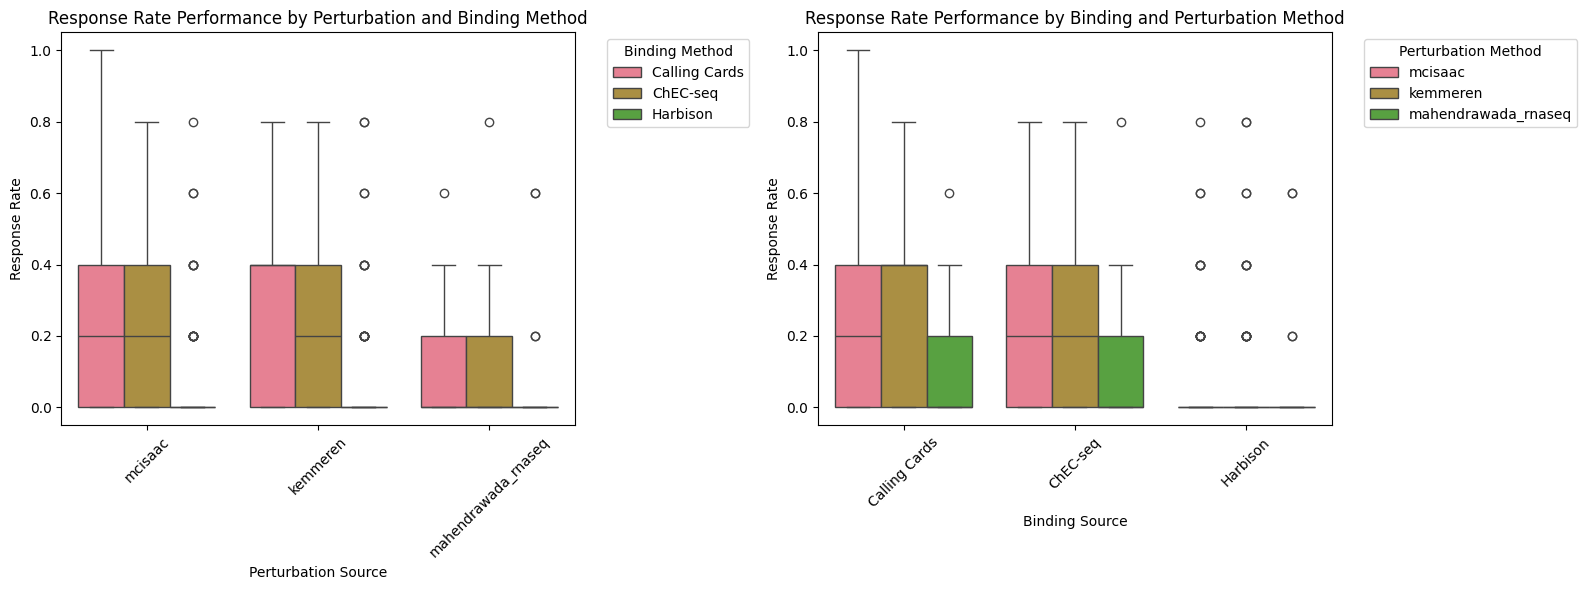

Summary Statistics by Method Combination:
                                    Count   Mean  Median    Std  Min  Max
binding_source perturbation_source                                       
Calling Cards  kemmeren                33  0.309     0.4  0.265  0.0  0.8
               mahendrawada_rnaseq     33  0.103     0.0  0.167  0.0  0.6
               mcisaac                 33  0.297     0.2  0.292  0.0  1.0
ChEC-seq       kemmeren                33  0.261     0.2  0.247  0.0  0.8
               mahendrawada_rnaseq     33  0.091     0.0  0.181  0.0  0.8
               mcisaac                 33  0.255     0.2  0.284  0.0  0.8
Harbison       kemmeren                81  0.074     0.0  0.177  0.0  0.8
               mahendrawada_rnaseq     81  0.020     0.0  0.098  0.0  0.6
               mcisaac                 81  0.064     0.0  0.158  0.0  0.8

Overall Performance by Binding Method:
                Count   Mean  Median    Std
binding_source                             
Calling Cards   

In [75]:

# Combine all rank-response results for comparison
combined_results = []

if len(cc_rr_res) > 0:
    cc_rr_res['binding_source'] = 'Calling Cards'
    combined_results.append(cc_rr_res)

if len(chec_rr_res) > 0:
    chec_rr_res['binding_source'] = 'ChEC-seq' 
    combined_results.append(chec_rr_res)

if len(harb_rr_res) > 0:
    harb_rr_res['binding_source'] = 'Harbison'
    combined_results.append(harb_rr_res)

if combined_results:
    all_rr_data = pd.concat(combined_results, ignore_index=True)

    # Create comparative boxplot visualizations
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 1. Combined boxplot - binding methods grouped by perturbation source
    sns.boxplot(data=all_rr_data, x='perturbation_source', y='response_rate', 
                hue='binding_source', ax=axes[0])
    axes[0].set_title('Response Rate Performance by Perturbation and Binding Method')
    axes[0].set_xlabel('Perturbation Source')
    axes[0].set_ylabel('Response Rate')
    axes[0].legend(title='Binding Method', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0].tick_params(axis='x', rotation=45)

    # 2. Faceted view - binding methods grouped by binding source  
    sns.boxplot(data=all_rr_data, x='binding_source', y='response_rate',
                hue='perturbation_source', ax=axes[1])
    axes[1].set_title('Response Rate Performance by Binding and Perturbation Method')
    axes[1].set_xlabel('Binding Source')
    axes[1].set_ylabel('Response Rate')
    axes[1].legend(title='Perturbation Method', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    # Summary statistics table
    print("Summary Statistics by Method Combination:")
    print("="*60)
    summary_stats = all_rr_data.groupby(['binding_source', 'perturbation_source']).agg({
        'response_rate': ['count', 'mean', 'median', 'std', 'min', 'max']
    }).round(3)
    summary_stats.columns = ['Count', 'Mean', 'Median', 'Std', 'Min', 'Max']
    print(summary_stats)

    # Overall performance by binding method
    print(f"\nOverall Performance by Binding Method:")
    print("="*40)
    binding_performance = all_rr_data.groupby('binding_source').agg({
        'response_rate': ['count', 'mean', 'median', 'std']
    }).round(3)
    binding_performance.columns = ['Count', 'Mean', 'Median', 'Std']
    print(binding_performance)

else:
    print("No results available for comparison visualization")